Rows: 8807
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
None

Missing values per column:
show_id            0
type               0
title              0
director        2634
cast

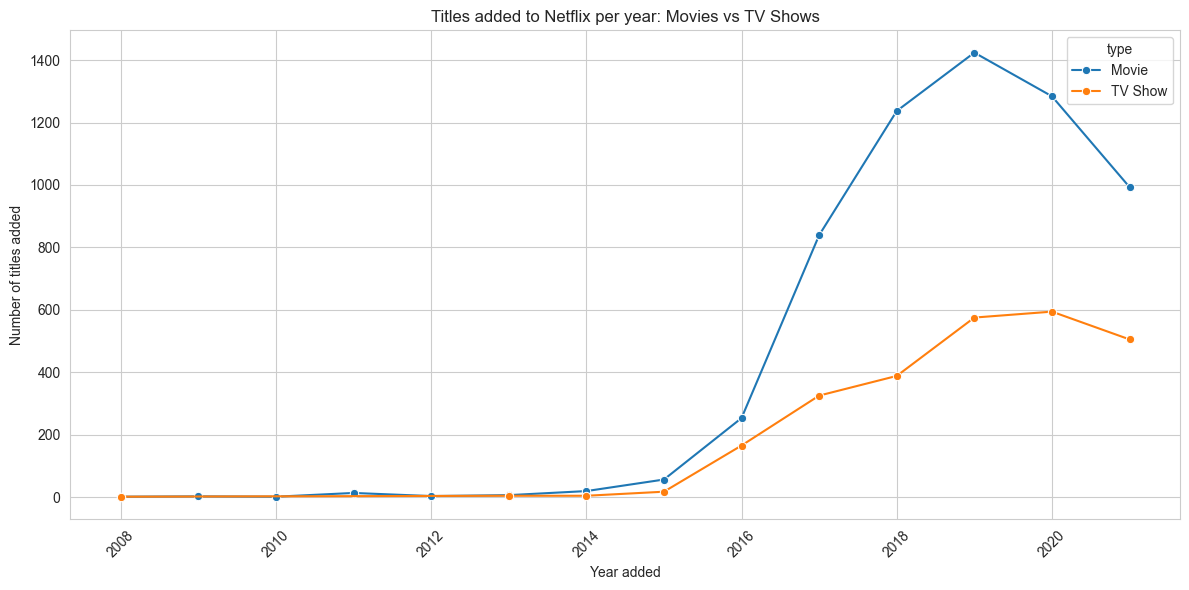

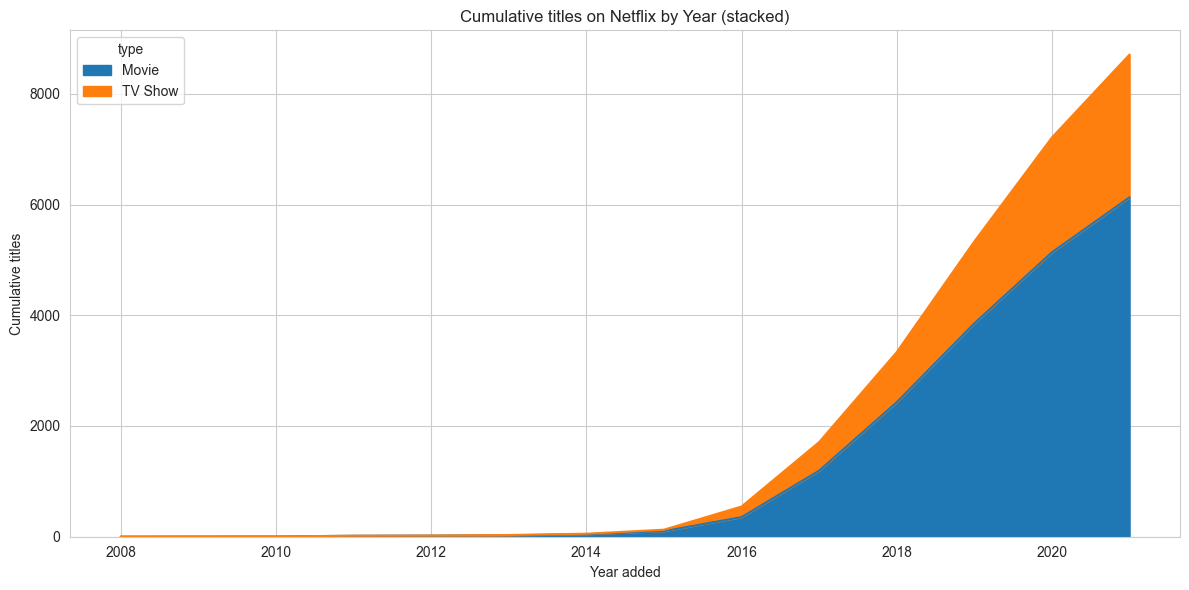

Top genres: ['International Movies', 'Dramas', 'Comedies', 'International TV Shows', 'Documentaries', 'Action & Adventure', 'TV Dramas', 'Independent Movies', 'Children & Family Movies', 'Romantic Movies', 'TV Comedies', 'Thrillers', 'Crime TV Shows', "Kids' TV", 'Docuseries']


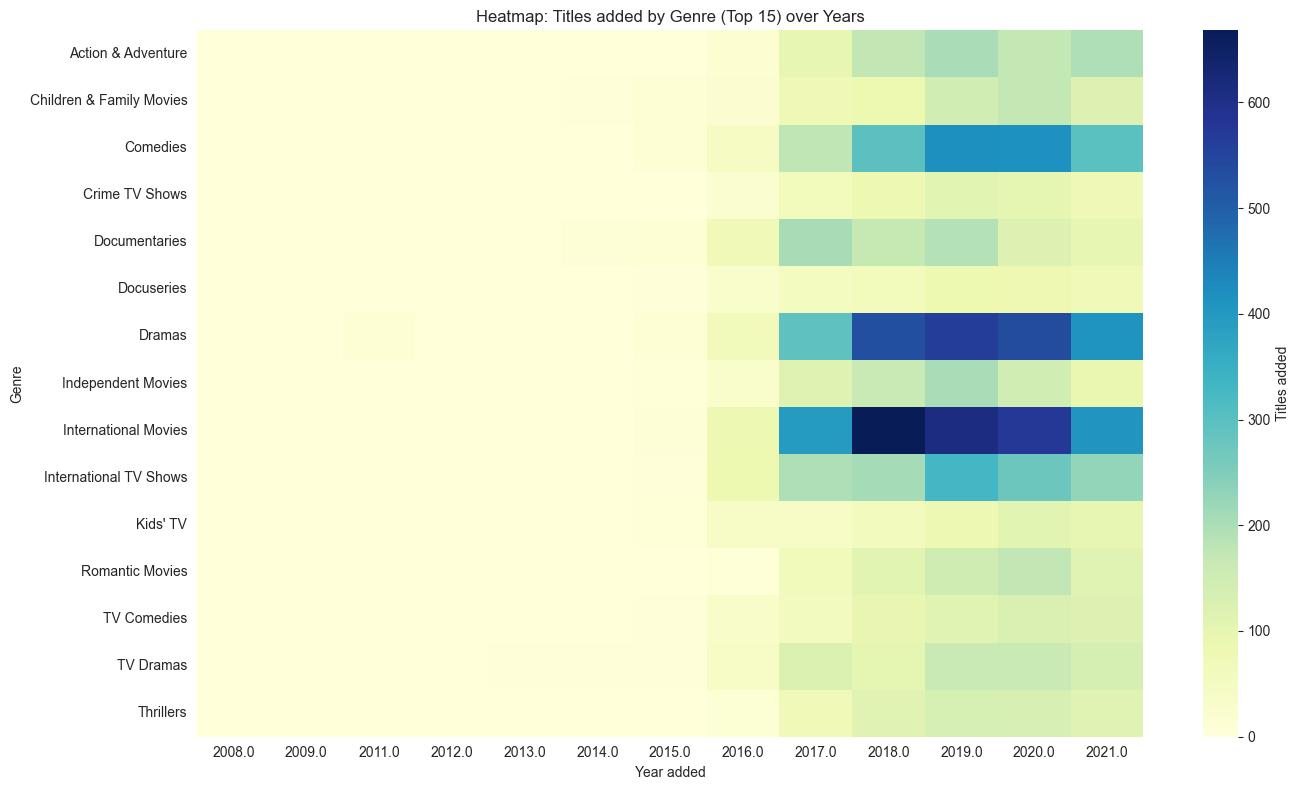

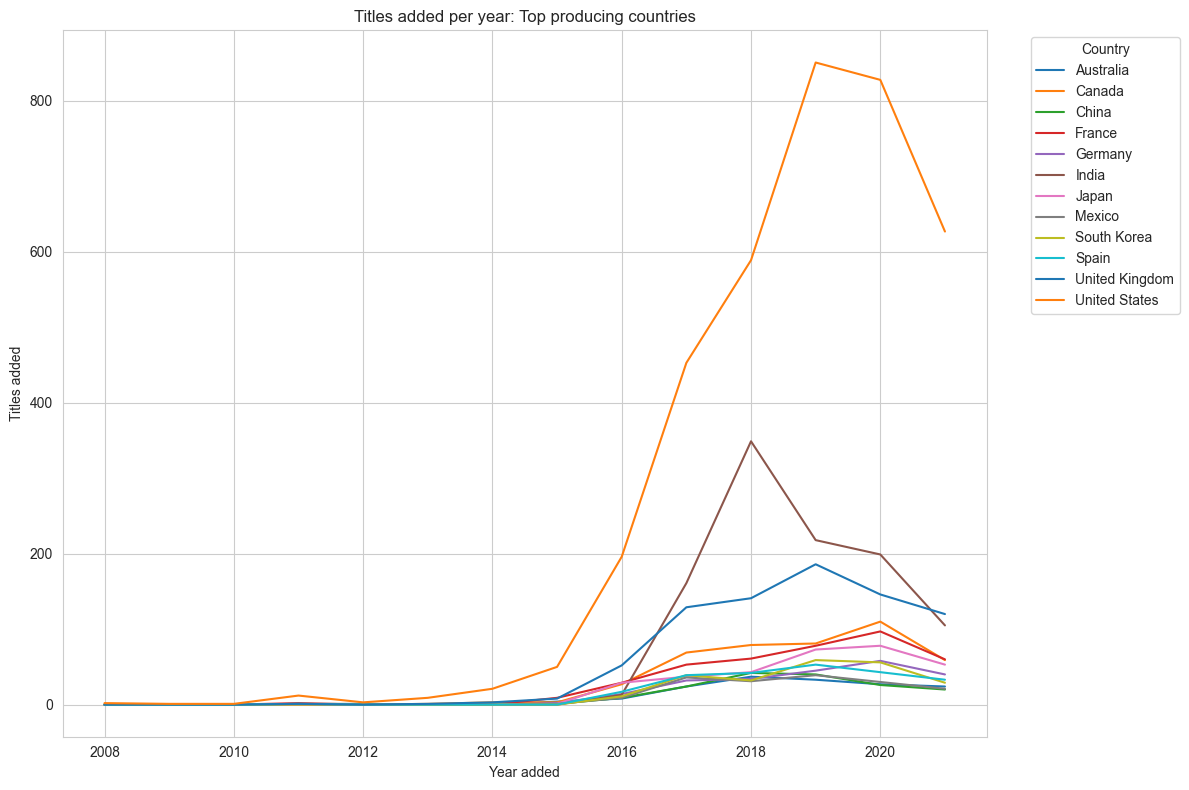

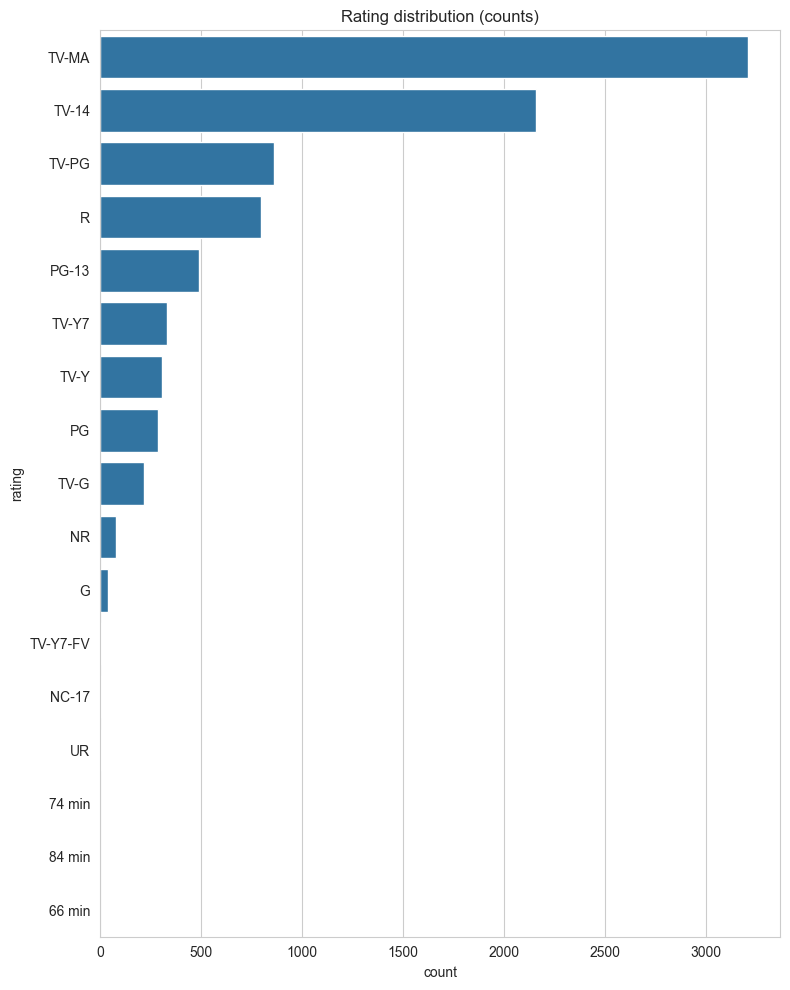

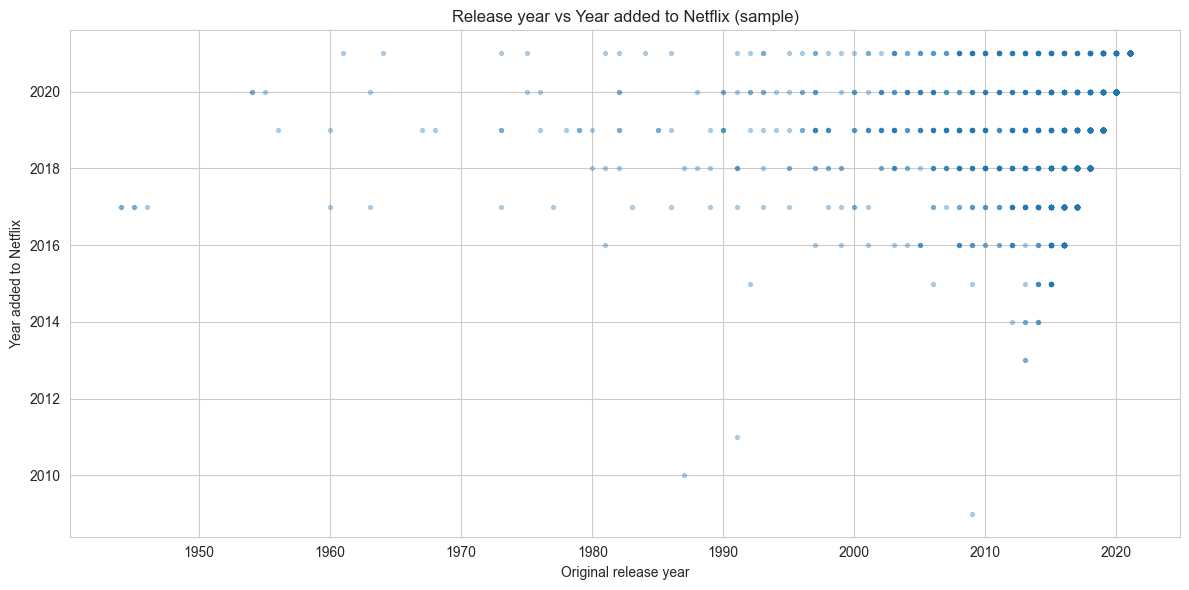

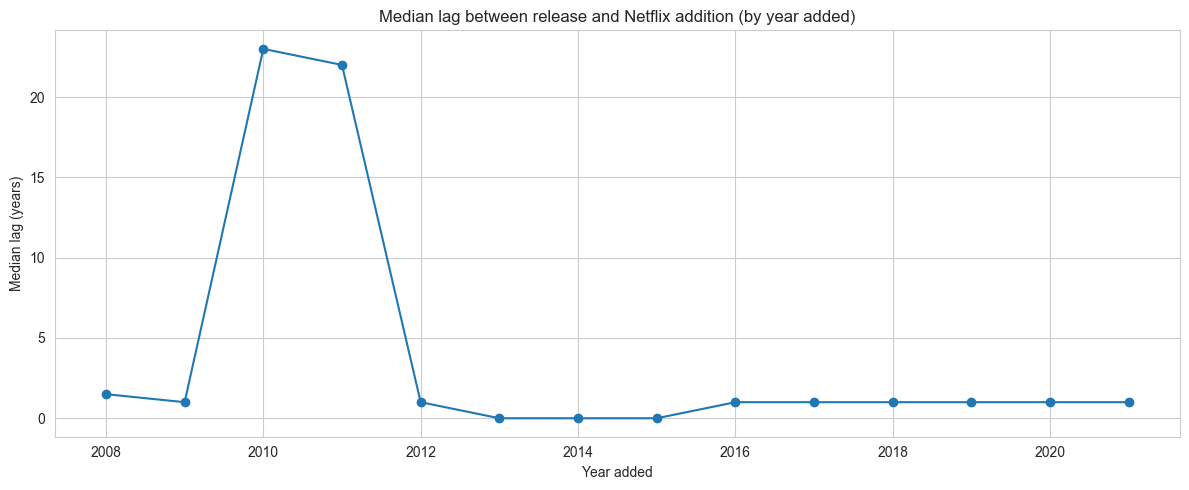

Top directors (by appearances):
director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Steven Spielberg       11
Don Michael Paul       10
David Dhawan            9
Yılmaz Erdoğan          9
Anurag Kashyap          9
Shannon Hartman         9
Quentin Tarantino       8
Robert Rodriguez        8
Hakan Algül             8
Hanung Bramantyo        8
Name: count, dtype: int64

Top cast members (by appearances):
cast
Anupam Kher          43
Shah Rukh Khan       35
Julie Tejwani        33
Naseeruddin Shah     32
Takahiro Sakurai     32
Rupa Bhimani         31
Akshay Kumar         30
Om Puri              30
Yuki Kaji            29
Amitabh Bachchan     28
Paresh Rawal         28
Boman Irani          27
Rajesh Kava          26
Vincent Tong         26
Andrea Libman        25
Kareena Kapo

In [4]:
# %% [markdown]
# Netflix Content Explorer — Full EDA Project
#
# This notebook contains a complete end-to-end Exploratory Data Analysis (EDA) project for the
# *Netflix Titles* dataset (Kaggle). It includes: data loading instructions, cleaning, exploratory
# analysis, visualizations, example interpretations, and optional extensions (report export,
# dashboard hints).
#
# ---
# **How to use**
# 1. Download `netflix_titles.csv` from: https://www.kaggle.com/datasets/shivamb/netflix-shows
#    and place it in the same folder as this notebook (or update the `DATA_PATH` below).
# 2. Run all cells in order. The notebook is structured with clear sections and helper functions.
# 3. Optional: install requirements with `pip install -r requirements.txt` or the single line below.
#
# Requirements (single line):
# pip install pandas matplotlib seaborn plotly jupyterlab openpyxl
#
# ---

# %%
# Core imports
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import textwrap

# Configure visuals
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# %%
# CONFIG
DATA_PATH = "netflix_titles.csv"  # change if needed
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# %% [markdown]
# ## 1 — Load data

# %%
# Load dataset (robustly)
if not Path(DATA_PATH).exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}. Download from Kaggle and place it there.")

df = pd.read_csv(DATA_PATH)
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

# Quick peek
(df
 .head(3)
 
 )

# %% [markdown]
# ## 2 — Initial inspection & cleaning

# %%
# Summary info
print(df.info())
print('\nMissing values per column:')
print(df.isnull().sum())

# %%
# Standardize column names (lowercase, underscores)
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

# Convert date_added to datetime (some rows may be NaN)
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Create helper columns
# year_added/month_added: when Netflix added the title to the library
# release_year: original release year (already present)

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Normalize text fields
for col in ['type', 'rating', 'duration', 'director', 'cast', 'country', 'listed_in']:
    if col in df.columns:
        df[col] = df[col].astype('string')

# Split duration: normalize movie minutes vs seasons
# For movies: duration like '90 min' -> minutes
# For TV shows: duration like '1 Season' or '4 Seasons' -> seasons

def parse_duration(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    if 'min' in x:
        try:
            return int(x.split()[0])
        except:
            return np.nan
    if 'Season' in x:
        try:
            return int(x.split()[0])
        except:
            return np.nan
    return np.nan

if 'duration' in df.columns:
    df['duration_parsed'] = df['duration'].apply(parse_duration)

# Clean up rating: map some common variants
rating_map = {
    '16+': '16+',
}
# keep as-is for now

# Show cleaned snapshot
print(df[['type','title','release_year','date_added','year_added','month_added','duration','duration_parsed']].head())

# %% [markdown]
# ## 3 — Missing values strategy & notes
# - `director`, `cast`, `country` and `rating` may have many missing values. We'll keep rows but mark 'Unknown' or NaN depending on analysis.
# - For time-series plots using `year_added`, we'll drop rows without `year_added`.

# %%
missing_summary = df.isna().mean().sort_values(ascending=False)
missing_summary = (missing_summary * 100).round(2)
missing_summary

# %% [markdown]
# ## 4 — High-level overview: counts, types, top countries/genres

# %%
print('Total titles:', len(df))
print(df['type'].value_counts(dropna=False))

# Top 12 countries (explode country field)
country_exploded = (
    df['country']
    .dropna()
    .str.split(',')
    .apply(lambda lst: [s.strip() for s in lst])
    .explode()
    .str.strip()
)
country_counts = country_exploded.value_counts()
country_counts.head(15)

# Top genres (listed_in) explode
genre_exploded = (
    df['listed_in']
    .dropna()
    .str.split(',')
    .apply(lambda lst: [s.strip() for s in lst])
    .explode()
)
genre_counts = genre_exploded.value_counts()
genre_counts.head(20)

# %% [markdown]
# ## 5 — Trends over time: Titles added per year (Movies vs TV Shows)

# %%
trend_df = (
    df.dropna(subset=['year_added'])
      .groupby(['year_added','type'])
      .size()
      .reset_index(name='count')
      .sort_values('year_added')
)

plt.figure(figsize=(12,6))
sns.lineplot(data=trend_df, x='year_added', y='count', hue='type', marker='o')
plt.title('Titles added to Netflix per year: Movies vs TV Shows')
plt.xlabel('Year added')
plt.ylabel('Number of titles added')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'titles_added_per_year.png')
plt.show()

# %% [markdown]
# ### Insight example
# Look at growth after 2015 and compare the shape for Movies and TV Shows. Consider cumulative counts to show library growth.

# %%
cum_df = (
    df.dropna(subset=['year_added'])
      .groupby(['year_added','type'])
      .size()
      .groupby(level=1).cumsum()
)

# The groupby above is a little cumbersome; build cumulative manually for clarity
pivot = trend_df.pivot(index='year_added', columns='type', values='count').fillna(0)
pivot_cum = pivot.cumsum()

pivot_cum.plot(kind='area', stacked=True, figsize=(12,6))
plt.title('Cumulative titles on Netflix by Year (stacked)')
plt.xlabel('Year added')
plt.ylabel('Cumulative titles')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cumulative_titles_by_year.png')
plt.show()

# %% [markdown]
# ## 6 — Genre analysis: Top genres and how they change over time

# %%
# Top 15 genres overall
top_genres = genre_counts.head(15).index.tolist()
print('Top genres:', top_genres)

# Build a year x genre matrix (counts of titles added that belong to the genre)
# We'll consider a title as belonging to multiple genres when listed_in includes multiple.

# Create exploded DF for genres with year_added
genre_year = (
    df.dropna(subset=['year_added'])
      .loc[:, ['title','year_added','listed_in']]
      .dropna(subset=['listed_in'])
      .assign(listed_in=lambda d: d['listed_in'].str.split(','))
      .explode('listed_in')
)
genre_year['listed_in'] = genre_year['listed_in'].str.strip()

# Filter to top genres
genre_year_top = genre_year[genre_year['listed_in'].isin(top_genres)]
genre_pivot = (
    genre_year_top
      .groupby(['year_added','listed_in'])
      .size()
      .reset_index(name='count')
      .pivot(index='year_added', columns='listed_in', values='count')
      .fillna(0)
)

# Plot a subset (heatmap) to visualize growth and decline
plt.figure(figsize=(14,8))
sns.heatmap(genre_pivot.transpose(), cmap='YlGnBu', cbar_kws={'label':'Titles added'})
plt.title('Heatmap: Titles added by Genre (Top 15) over Years')
plt.xlabel('Year added')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'genre_heatmap_top15.png')
plt.show()

# %% [markdown]
# ## 7 — Country analysis: top producing countries and trends

# %%
country_year = (
    df.dropna(subset=['year_added'])
      .loc[:, ['title','year_added','country']]
      .dropna(subset=['country'])
      .assign(country=lambda d: d['country'].str.split(','))
      .explode('country')
)
country_year['country'] = country_year['country'].str.strip()

# Top 12 countries overall
top_countries = country_year['country'].value_counts().head(12).index.tolist()

cy_pivot = (
    country_year[country_year['country'].isin(top_countries)]
      .groupby(['year_added','country'])
      .size()
      .reset_index(name='count')
      .pivot(index='year_added', columns='country', values='count')
      .fillna(0)
)

# Plot the top countries trends
cy_pivot.plot(figsize=(12,8))
plt.title('Titles added per year: Top producing countries')
plt.xlabel('Year added')
plt.ylabel('Titles added')
plt.legend(title='Country', bbox_to_anchor=(1.04,1), loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'country_trends_top12.png')
plt.show()

# %% [markdown]
# ## 8 — Rating distribution and audience analysis

# %%
if 'rating' in df.columns:
    rating_order = df['rating'].value_counts().index.tolist()
    plt.figure(figsize=(8,10))
    sns.countplot(y='rating', data=df, order=rating_order)
    plt.title('Rating distribution (counts)')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'rating_distribution.png')
    plt.show()

# %% [markdown]
# ## 9 — Release year vs Netflix-added year (aging of content)

# %%
plt.figure(figsize=(12,6))
# scatter: release_year vs year_added
sample = df.dropna(subset=['year_added','release_year']).sample(n=min(2000, len(df.dropna(subset=['year_added','release_year']))), random_state=42)
plt.scatter(sample['release_year'], sample['year_added'], alpha=0.3, s=8)
plt.title('Release year vs Year added to Netflix (sample)')
plt.xlabel('Original release year')
plt.ylabel('Year added to Netflix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'release_vs_added_scatter.png')
plt.show()

# Compute median lag (year_added - release_year) per added year
lag_df = df.dropna(subset=['year_added','release_year']).copy()
lag_df['lag_years'] = lag_df['year_added'] - lag_df['release_year']
median_lag = lag_df.groupby('year_added')['lag_years'].median()

plt.figure(figsize=(12,5))
median_lag.plot(marker='o')
plt.title('Median lag between release and Netflix addition (by year added)')
plt.xlabel('Year added')
plt.ylabel('Median lag (years)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'median_lag_release_to_added.png')
plt.show()

# %% [markdown]
# ## 10 — Popular directors / cast (simple frequency analysis)

# %%
# Directors — many missing values; explode
if 'director' in df.columns:
    director_exploded = (df['director'].dropna().str.split(',').apply(lambda lst: [s.strip() for s in lst]).explode())
    top_directors = director_exploded.value_counts().head(20)
    print('Top directors (by appearances):')
    print(top_directors)

# Cast — top cast members
if 'cast' in df.columns:
    cast_exploded = (df['cast'].dropna().str.split(',').apply(lambda lst: [s.strip() for s in lst]).explode())
    top_cast = cast_exploded.value_counts().head(25)
    print('\nTop cast members (by appearances):')
    print(top_cast)

# %% [markdown]
# ## 11 — Save key summary tables to Excel for reporting

# %%
summary_tables = {
    'overview_counts': df['type'].value_counts(),
    'top_genres': genre_counts.head(30),
    'top_countries': country_counts.head(30),
    'top_directors': top_directors if 'top_directors' in locals() else pd.Series(),
    'top_cast': top_cast if 'top_cast' in locals() else pd.Series(),
}
with pd.ExcelWriter(OUTPUT_DIR / 'netflix_summary_tables.xlsx') as writer:
    for name, table in summary_tables.items():
        if table is None or (isinstance(table, pd.Series) and table.empty):
            continue
        table.to_excel(writer, sheet_name=name[:31])

print('Saved summary tables to outputs/netflix_summary_tables.xlsx')

# %% [markdown]
# ## 12 — Implemented analyses (requested)


# %%
# --- IMPLEMENTED ANALYSES: helper plotting & analysis functions

def analyze_type_trends(df, output_dir=OUTPUT_DIR, save=True):
    """Movies vs TV Shows: yearly counts, percent share, stacked area plot."""
    tdf = df.dropna(subset=['year_added']).groupby(['year_added','type']).size().reset_index(name='count')
    # Yearly counts pivot
    pivot = tdf.pivot(index='year_added', columns='type', values='count').fillna(0)
    # Percent share
    percent = pivot.div(pivot.sum(axis=1), axis=0) * 100

    # Line plot of counts
    plt.figure(figsize=(12,6))
    sns.lineplot(data=tdf, x='year_added', y='count', hue='type', marker='o')
    plt.title('Titles added per year by Type')
    plt.tight_layout()
    if save:
        plt.savefig(output_dir / 'type_trends_counts.png')
    plt.show()

    # Percent stacked area
    percent.plot(kind='area', stacked=True, figsize=(12,6))
    plt.title('Percentage share by Type (per year)')
    plt.ylabel('Percent (%)')
    plt.xlabel('Year added')
    plt.tight_layout()
    if save:
        plt.savefig(output_dir / 'type_trends_percent.png')
    plt.show()

    return pivot, percent

# %%

def analyze_genre_popularity(df, top_n=15, output_dir=OUTPUT_DIR, save=True):
    """Top genres overall and how they evolve by year. Returns genre counts and pivot table."""
    # explode genres
    g = df['listed_in'].dropna().str.split(',').apply(lambda lst: [s.strip() for s in lst]).explode()
    genre_counts = g.value_counts()
    top_genres = genre_counts.head(top_n).index.tolist()

    # Bar chart of top genres
    plt.figure(figsize=(10,6))
    sns.barplot(x=genre_counts.loc[top_genres].values, y=genre_counts.loc[top_genres].index)
    plt.title(f'Top {top_n} Genres (overall)')
    plt.xlabel('Count')
    plt.tight_layout()
    if save:
        plt.savefig(output_dir / 'top_genres_bar.png')
    plt.show()

    # Year x Genre pivot for top genres
    genre_year = (
        df.dropna(subset=['year_added'])
          .loc[:, ['title','year_added','listed_in']]
          .dropna(subset=['listed_in'])
          .assign(listed_in=lambda d: d['listed_in'].str.split(','))
          .explode('listed_in')
    )
    genre_year['listed_in'] = genre_year['listed_in'].str.strip()
    gy_top = genre_year[genre_year['listed_in'].isin(top_genres)]
    genre_pivot = (gy_top.groupby(['year_added','listed_in']).size().reset_index(name='count')
                   .pivot(index='year_added', columns='listed_in', values='count').fillna(0))

    plt.figure(figsize=(14,8))
    sns.heatmap(genre_pivot.transpose(), cmap='YlOrBr', cbar_kws={'label': 'Titles added'})
    plt.title('Genre trends (Top genres) over years')
    plt.xlabel('Year added')
    plt.ylabel('Genre')
    plt.tight_layout()
    if save:
        plt.savefig(output_dir / 'genre_trends_heatmap.png')
    plt.show()

    return genre_counts, genre_pivot

# %%

def analyze_country_production(df, top_n=12, output_dir=OUTPUT_DIR, save=True):
    """Country-wise production: top countries and per-year trends for top countries."""
    country_exploded = (df['country'].dropna().str.split(',').apply(lambda lst: [s.strip() for s in lst]).explode())
    country_counts = country_exploded.value_counts()
    top_countries = country_counts.head(top_n).index.tolist()

    # Bar chart
    plt.figure(figsize=(10,6))
    sns.barplot(x=country_counts.loc[top_countries].values, y=country_counts.loc[top_countries].index)
    plt.title(f'Top {top_n} Producing Countries (overall)')
    plt.xlabel('Titles')
    plt.tight_layout()
    if save:
        plt.savefig(output_dir / 'top_countries_bar.png')
    plt.show()

    # Yearly trends for top countries
    country_year = (
        df.dropna(subset=['year_added'])
          .loc[:, ['title','year_added','country']]
          .dropna(subset=['country'])
          .assign(country=lambda d: d['country'].str.split(','))
          .explode('country')
    )
    country_year['country'] = country_year['country'].str.strip()
    cy_pivot = (country_year[country_year['country'].isin(top_countries)]
                .groupby(['year_added','country']).size().reset_index(name='count')
                .pivot(index='year_added', columns='country', values='count').fillna(0))

    cy_pivot.plot(figsize=(12,8))
    plt.title('Titles added per year: Top producing countries')
    plt.xlabel('Year added')
    plt.ylabel('Titles added')
    plt.legend(title='Country', bbox_to_anchor=(1.04,1), loc='upper left')
    plt.tight_layout()
    if save:
        plt.savefig(output_dir / 'country_trends_top.png')
    plt.show()

    # Save a map-ready table (country -> total titles)
    country_table = country_counts.reset_index()
    country_table.columns = ['country', 'titles']
    if save:
        country_table.to_csv(output_dir / 'country_table.csv', index=False)

    return country_counts, cy_pivot

# %%

def analyze_ratings(df, output_dir=OUTPUT_DIR, save=True):
    """Ratings & audience categories: distribution and trends by type."""
    if 'rating' not in df.columns:
        print('No rating column available')
        return None

    # Distribution
    order = df['rating'].value_counts().index.tolist()
    plt.figure(figsize=(8,10))
    sns.countplot(y='rating', data=df, order=order)
    plt.title('Rating distribution')
    plt.tight_layout()
    if save:
        plt.savefig(output_dir / 'rating_distribution_counts.png')
    plt.show()

    # Ratings by Type (Movies vs TV Shows)
    rtype = df.dropna(subset=['rating']).groupby(['type','rating']).size().reset_index(name='count')
    pivot = rtype.pivot(index='rating', columns='type', values='count').fillna(0)

    pivot.plot(kind='bar', figsize=(10,6))
    plt.title('Rating counts by Type')
    plt.xlabel('Rating')
    plt.ylabel('Count')
    plt.tight_layout()
    if save:
        plt.savefig(output_dir / 'rating_by_type.png')
    plt.show()

    # Year-wise trend: top 6 ratings over time
    top_ratings = df['rating'].value_counts().head(6).index.tolist()
    ry = df.dropna(subset=['year_added','rating']).loc[:, ['year_added','rating']]
    ry = ry[ry['rating'].isin(top_ratings)]
    ry_pivot = ry.groupby(['year_added','rating']).size().reset_index(name='count').pivot(index='year_added', columns='rating', values='count').fillna(0)

    ry_pivot.plot(figsize=(12,6))
    plt.title('Year-wise trend: Top Ratings')
    plt.xlabel('Year added')
    plt.ylabel('Count')
    plt.tight_layout()
    if save:
        plt.savefig(output_dir / 'ratings_trend_top.png')
    plt.show()

    return pivot, ry_pivot

# %%

def analyze_release_year_patterns(df, output_dir=OUTPUT_DIR, save=True):
    """Release year patterns: histogram, median lag, and aging (lag) analysis."""
    # Histogram of release years
    plt.figure(figsize=(12,6))
    df['release_year'].dropna().astype(int).plot(kind='hist', bins=40)
    plt.title('Distribution of Original Release Years')
    plt.xlabel('Release Year')
    plt.tight_layout()
    if save:
        plt.savefig(output_dir / 'release_year_hist.png')
    plt.show()

    # Median/mean release year per year_added
    r = df.dropna(subset=['year_added','release_year']).copy()
    r['release_year'] = r['release_year'].astype(int)
    stats = r.groupby('year_added')['release_year'].agg(['median','mean']).sort_index()

    stats.plot(figsize=(12,5))
    plt.title('Median & Mean original release year for titles added (by year_added)')
    plt.xlabel('Year added')
    plt.ylabel('Release year')
    plt.tight_layout()
    if save:
        plt.savefig(output_dir / 'release_year_stats_by_added.png')
    plt.show()

    # Aging lag analysis
    r['lag_years'] = r['year_added'] - r['release_year']
    lag_median = r.groupby('year_added')['lag_years'].median()
    plt.figure(figsize=(12,5))
    lag_median.plot(marker='o')
    plt.title('Median lag between release and Netflix addition')
    plt.xlabel('Year added')
    plt.ylabel('Median lag (years)')
    plt.tight_layout()
    if save:
        plt.savefig(output_dir / 'median_lag_release_to_added_impl.png')
    plt.show()

    return stats, lag_median

# %%
# Example: run all analyses (uncomment to run)
# type_pivot, type_percent = analyze_type_trends(df)
# genre_counts, genre_pivot = analyze_genre_popularity(df)
# country_counts, country_pivot = analyze_country_production(df)
# rating_pivot, ratings_trend = analyze_ratings(df)
# release_stats, lag_median = analyze_release_year_patterns(df)

# %% [markdown]
# ## 13 — How to run these analyses interactively
# 
# You can run any analysis function above in a single cell. For example:
# ```python
# type_pivot, type_percent = analyze_type_trends(df)
# genre_counts, genre_pivot = analyze_genre_popularity(df, top_n=20)
# ```
# 
# Each function returns the summary tables / pivots so you can inspect them programmatically, and also saves charts to the `outputs/` folder.

# %% [markdown]
# ---
# End of updated notebook. The requested analyses are implemented as functions — open the notebook in VS Code, run the final cells to execute them, or ask me to run specific analyses here if you upload the CSV.
